# PCA analysis of the hidden layer

Does an RNN trained on the Kalman
filtering task represent posterior uncertainty (`sigma_sq`) and the posterior mean
estimate (`mu`) along *different* directions in its 200-unit hidden state (`r_hid`),
or are the two tangled together on the same directions?

If the hidden layer's own natural axes of variation (found here with
PCA, which has no knowledge of `sigma_sq` or `mu` at all) happen to separate the two,
that's evidence the network organized a genuinely factorized code on its own.

**What PCA is being run on:** the pooled hidden-layer activations (`r_hid`) across
many (trial, timestep) samples -- *not* on `sigma_sq`, `mu`, or the raw input. PCA
finds the directions along which `r_hid` varies the most, with no knowledge of the
two variables we'll check it against afterward.


In [1]:
try:
    import google.colab  # noqa: F401
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    #!git clone https://github.com/jgrk28/kalnet.git #uncomment if loading from colab without connecting to GitHub
    %cd /content/kalnet
    %pip install -e .
else:
    #update for your local path
    %cd /home/jacob/kalnet

/home/jacob/kalnet


Imports

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import torch
from pathlib import Path

from kalnet.task_vec import KalmanFilteringTask
from kalnet.model import KalmanRNN


In [3]:
from scipy.stats import pearsonr
from sklearn.decomposition import PCA
import os

## Collect hidden states from the trained network

Before we can look at the hidden layer's geometry, we need to actually **run the
trained network forward** on many trials and record what its hidden units do at
every timestep. This is the same `collect()` pattern used throughout this
project. Alongside the network's own hidden
states (`r_hid`) and output (`s_hat`), we also record the **ground-truth**
optimal mean (`mu`) and posterior variance (`sigma_sq`) for that exact same
trial, computed analytically -- these are what we'll check the hidden states
against, and the network never saw either of them during training.

In [4]:
def collect(task: KalmanFilteringTask, net: KalmanRNN, n_trials: int, device: str = "cpu"):
    """Collect hidden states + ground truth for n_trials, in chunks of task.batch_size.
    task should already be constructed with the batch_size/tr_cond/seed """

    net.eval()
    all_r_hid, all_s, all_g, all_mu, all_sigma_sq, all_s_hat = [], [], [], [], [], []

    n_collected = 0
    with torch.no_grad():
        while n_collected < n_trials:
            batch = task.sample(include_internals=True)

            y, hidden = net(batch.input.to(device), return_hidden=True)
            # squeeze away the trailing singleton feature dim to match this
            # project's (n_trials, T) convention throughout
            s_hat = y[:, :, 0]
            s = batch.target[:, :, 0].to(device)
            g = batch.internals.gain[:, :, 0].to(device)
            mu = batch.opt_mean[:, :, 0].to(device)
            sigma_sq = batch.internals.opt_var[:, :, 0].to(device)

            all_r_hid.append(hidden.cpu())
            all_s.append(s.cpu())
            all_g.append(g.cpu())
            all_mu.append(mu.cpu())
            all_sigma_sq.append(sigma_sq.cpu())
            all_s_hat.append(s_hat.cpu())

            n_collected += batch.input.shape[0]  # = task.batch_size, each call

    return {
        "r_hid": torch.cat(all_r_hid, dim=0)[:n_trials],
        "s": torch.cat(all_s, dim=0)[:n_trials],
        "g": torch.cat(all_g, dim=0)[:n_trials],
        "mu": torch.cat(all_mu, dim=0)[:n_trials],
        "sigma_sq": torch.cat(all_sigma_sq, dim=0)[:n_trials],
        "s_hat": torch.cat(all_s_hat, dim=0)[:n_trials],
    }


Load the trained checkpoint and collect a held-out set of trials. We use a
fixed, dedicated `seed` for this task instance so the collected dataset is
reproducible -- rerunning this cell should always draw the same trials.

In [9]:
device = "cpu"
checkpoint = torch.load("checkpoints/kf_allgain_100batch.pt", map_location=device, weights_only=False)
net = KalmanRNN(
    n_in=checkpoint["config"]["n_in"],
    n_hid=checkpoint["config"]["n_hid"],
    n_out=1,
).to(device)
net.load_state_dict(checkpoint["state_dict"])
print("Loaded trained network.")

# One KalmanFilteringTask instance per split, each with its own widely-separated
# seed (matching the original collect_data.py's non-overlapping-draws guarantee),
# and each fixed to a convenient batch_size for chunked collection.
train_task = KalmanFilteringTask(batch_size=500, tr_cond="all_gains", seed=1000, device=device)
test_task = KalmanFilteringTask(batch_size=500, tr_cond="all_gains", seed=2000, device=device)
print("Collecting training set (normal trials)...")
train_data = collect(train_task, net, n_trials=5000, device=device)

print("Collecting held-out test set (normal trials)...")
test_data = collect(test_task, net, n_trials=2000, device=device)

torch.save(
    {"train": train_data, "test": test_data},
    "saved_data/kf_dataset_100.pt",
)
print("Saved kf_dataset_100.pt")
print(f"  train:    r_hid {train_data['r_hid'].shape}")
print(f"  test:     r_hid {test_data['r_hid'].shape}")

Loaded trained network.
Saved kf_dataset_100.pt
  train:    r_hid torch.Size([5000, 25, 200])
  test:     r_hid torch.Size([2000, 25, 200])


##PCA on the pooled hidden states

Every (trial, timestep) pair gives one 200-dimensional `r_hid` vector -- pooling
across all trials and timesteps in the test set gives many thousands of such
points. PCA finds the directions in this 200-dimensional space along which
these points vary the most, entirely unsupervised (it never sees `sigma_sq` or
`mu` while fitting).

**Two things this analysis checks, in order:**

1. **Effective dimensionality** -- how many components does it actually take to
   explain most (e.g. 95%) of the population's variance? If this is much less
   than 200, the network's code is meaningfully compressed relative to its
   nominal capacity.
2. **Which components track which variable** -- correlating each of the top
   PCs against `sigma_sq` and `mu` separately. If a different component
   dominates each variable (e.g. PC1 tracks `mu` strongly while `sigma_sq` is
   concentrated on PC2 or PC3), that's suggestive of at least partial
   separation between the two codes.



In [10]:
def flatten_multi(split):
    r_hid = split["r_hid"].reshape(-1, split["r_hid"].shape[-1]).numpy()
    sigma_sq = split["sigma_sq"].reshape(-1).numpy()
    mu = split["mu"].reshape(-1).numpy()
    return r_hid, sigma_sq, mu

def pca_analysis(dataset_path: str = 'kf_dataset.pt', output_plot_path: str = "pca_results.png",
        show: bool = True, n_components_look: int = 10, variance_threshold: float = 0.95):
    """Run the PCA analysis on a collected dataset.

    n_components_look: how many top PCs to examine individually (correlate
        against sigma_sq and mu, show in the bar-chart panels).
    variance_threshold: reported in the printout as "how many components does
        it actually take to explain this much of the population's variance"

    Returns a dict of headline numbers so results can be compared across
    multiple networks/datasets programmatically"""

    data = torch.load(dataset_path, weights_only=False)
    test = data["test"]
    X_test, sigma_sq_test, mu_test = flatten_multi(test)

    print(f"[{dataset_path}] Pooled test samples: {X_test.shape[0]}, hidden units: {X_test.shape[1]}\n")


    # Fit PCA (full rank, to get the complete variance-explained curve)

    n_full = min(X_test.shape[0], X_test.shape[1])
    pca_full = PCA(n_components=n_full, random_state=0)
    pca_full.fit(X_test)
    cum_var = np.cumsum(pca_full.explained_variance_ratio_)
    n_needed = int(np.searchsorted(cum_var, variance_threshold) + 1)

    print("=" * 60)
    print("1. EFFECTIVE DIMENSIONALITY")
    print("=" * 60)
    print(f"  Components needed for {variance_threshold*100:.0f}% of variance: "
          f"{n_needed} (out of {X_test.shape[1]} hidden units)")
    print(f"  Variance explained by top 1 component:  {pca_full.explained_variance_ratio_[0]*100:.1f}%")
    print(f"  Variance explained by top {n_components_look} components: {cum_var[n_components_look-1]*100:.1f}%")


    # Project onto the top n_components_look PCs, correlate each against sigma_sq and mu separately

    n_look = min(n_components_look, n_full)
    X_pca = pca_full.transform(X_test)[:, :n_look]

    print("\n" + "=" * 60)
    print(f"2. TOP {n_look} PCs vs. sigma_sq and mu")
    print("=" * 60)
    corr_sigma = np.zeros(n_look)
    corr_mu = np.zeros(n_look)
    for i in range(n_look):
        corr_sigma[i], _ = pearsonr(X_pca[:, i], sigma_sq_test)
        corr_mu[i], _ = pearsonr(X_pca[:, i], mu_test)
        print(f"  PC{i+1:2d}  var={pca_full.explained_variance_ratio_[i]*100:5.1f}%   "
              f"corr(sigma_sq)={corr_sigma[i]:+.3f}   corr(mu)={corr_mu[i]:+.3f}")

    top_sigma_pc = int(np.argmax(np.abs(corr_sigma)))
    top_mu_pc = int(np.argmax(np.abs(corr_mu)))
    print(f"\n  --> Strongest sigma_sq component: PC{top_sigma_pc+1} (r={corr_sigma[top_sigma_pc]:+.3f})")
    print(f"  --> Strongest mu component:       PC{top_mu_pc+1} (r={corr_mu[top_mu_pc]:+.3f})")
    if top_sigma_pc == top_mu_pc:
        print("  --> SAME component dominates both -- mean and uncertainty are entangled on this axis")
    else:
        print("  --> DIFFERENT components dominate -- some separation between mean and uncertainty axes")


    # PLOTS

    rng = np.random.default_rng(0)
    n_plot = 3000
    idx = rng.choice(len(sigma_sq_test), size=min(n_plot, len(sigma_sq_test)), replace=False)

    # Derive per-plot filenames from output_plot_path, e.g.
    # "pca_results.png" -> "pca_results_scree.png", "pca_results_cumvar.png", ...
    base, ext = os.path.splitext(output_plot_path)
    suffixes = ["scree", "cumvar", "pc_corr_bars", "pc1_pc2_sigma", "pc1_pc2_mu", "best_axes"]
    plot_paths = {name: f"{base}_{name}{ext}" for name in suffixes}

    # Plot 1: variance explained per PC
    n_scree = min(15, n_full)
    fig1, ax1 = plt.subplots(figsize=(6, 4.5))
    ax1.bar(range(1, n_scree + 1), pca_full.explained_variance_ratio_[:n_scree] * 100)
    ax1.set_xlabel("principal component")
    ax1.set_ylabel("% variance explained")
    ax1.set_title("Top 15 PCs")
    fig1.suptitle(dataset_path, fontsize=9)
    fig1.tight_layout()
    fig1.savefig(plot_paths["scree"], dpi=120)
    plt.show() if show else plt.close(fig1)

    # Plot 2: cumulative variance explained
    fig2, ax2 = plt.subplots(figsize=(6, 4.5))
    ax2.plot(range(1, n_full + 1), cum_var * 100, "-")
    ax2.axhline(variance_threshold * 100, color="gray", linestyle="--", linewidth=1,
                label=f"{variance_threshold*100:.0f}% threshold")
    ax2.axvline(n_needed, color="red", linestyle="--", linewidth=1,
                label=f"{n_needed} components")
    ax2.set_xlabel("number of components")
    ax2.set_ylabel("cumulative % variance")
    ax2.set_title("Cumulative variance explained")
    ax2.legend()
    ax2.set_xlim(0, min(50, n_full))
    fig2.suptitle(dataset_path, fontsize=9)
    fig2.tight_layout()
    fig2.savefig(plot_paths["cumvar"], dpi=120)
    plt.show() if show else plt.close(fig2)

    # Plot 3: |correlation| of each top PC with sigma_sq vs. mu, side by side
    fig3, ax3 = plt.subplots(figsize=(7, 4.5))
    x = np.arange(n_look)
    width = 0.35
    ax3.bar(x - width/2, np.abs(corr_sigma), width, label="sigma_sq", color="tab:blue")
    ax3.bar(x + width/2, np.abs(corr_mu), width, label="mean", color="tab:green")
    ax3.set_xticks(x, [f"PC{i+1}" for i in range(n_look)])
    ax3.set_ylabel("|correlation|")
    ax3.set_title("Which PCs track sigma_sq, mean")
    ax3.legend()
    fig3.suptitle(dataset_path, fontsize=9)
    fig3.tight_layout()
    fig3.savefig(plot_paths["pc_corr_bars"], dpi=120)
    plt.show() if show else plt.close(fig3)

    # Plot 4: PC1 vs PC2, colored by sigma_sq
    fig4, ax4 = plt.subplots(figsize=(6, 5))
    sc1 = ax4.scatter(X_pca[idx, 0], X_pca[idx, 1], c=sigma_sq_test[idx],
                       cmap="viridis", s=6, alpha=0.6)
    ax4.set_xlabel("PC1")
    ax4.set_ylabel("PC2")
    ax4.set_title("PC1 vs PC2, colored by sigma_sq")
    fig4.colorbar(sc1, ax=ax4, label="sigma_sq")
    fig4.suptitle(dataset_path, fontsize=9)
    fig4.tight_layout()
    fig4.savefig(plot_paths["pc1_pc2_sigma"], dpi=120)
    plt.show() if show else plt.close(fig4)

    # Plot 5: PC1 vs PC2, colored by mean
    fig5, ax5 = plt.subplots(figsize=(6, 5))
    sc2 = ax5.scatter(X_pca[idx, 0], X_pca[idx, 1], c=mu_test[idx],
                       cmap="coolwarm", s=6, alpha=0.6)
    ax5.set_xlabel("PC1")
    ax5.set_ylabel("PC2")
    ax5.set_title("PC1 vs PC2, colored by mean")
    fig5.colorbar(sc2, ax=ax5, label="mean")
    fig5.suptitle(dataset_path, fontsize=9)
    fig5.tight_layout()
    fig5.savefig(plot_paths["pc1_pc2_mu"], dpi=120)
    plt.show() if show else plt.close(fig5)

    for name, path in plot_paths.items():
        print(f"Saved {path}")


    return {
        "dataset_path": dataset_path,
        "n_components_for_95pct": n_needed,
        "pc1_variance_pct": pca_full.explained_variance_ratio_[0] * 100,
        "top_sigma_pc": top_sigma_pc + 1,
        "top_sigma_pc_corr": corr_sigma[top_sigma_pc],
        "top_mu_pc": top_mu_pc + 1,
        "top_mu_pc_corr": corr_mu[top_mu_pc],
        "same_pc_dominates_both": top_sigma_pc == top_mu_pc,
    }



[saved_data/kf_dataset_100.pt] Pooled test samples: 50000, hidden units: 200

1. EFFECTIVE DIMENSIONALITY
  Components needed for 95% of variance: 44 (out of 200 hidden units)
  Variance explained by top 1 component:  38.7%
  Variance explained by top 10 components: 77.2%

2. TOP 10 PCs vs. sigma_sq and mu
  PC 1  var= 38.7%   corr(sigma_sq)=+0.024   corr(mu)=-0.971
  PC 2  var= 13.5%   corr(sigma_sq)=-0.637   corr(mu)=-0.027
  PC 3  var=  6.5%   corr(sigma_sq)=+0.004   corr(mu)=+0.005
  PC 4  var=  5.4%   corr(sigma_sq)=-0.509   corr(mu)=-0.038
  PC 5  var=  4.1%   corr(sigma_sq)=-0.031   corr(mu)=+0.179
  PC 6  var=  2.1%   corr(sigma_sq)=+0.023   corr(mu)=-0.026
  PC 7  var=  2.1%   corr(sigma_sq)=-0.002   corr(mu)=+0.014
  PC 8  var=  1.8%   corr(sigma_sq)=+0.040   corr(mu)=+0.021
  PC 9  var=  1.7%   corr(sigma_sq)=+0.107   corr(mu)=+0.001
  PC10  var=  1.4%   corr(sigma_sq)=-0.005   corr(mu)=-0.031

  --> Strongest sigma_sq component: PC2 (r=-0.637)
  --> Strongest mu component: 

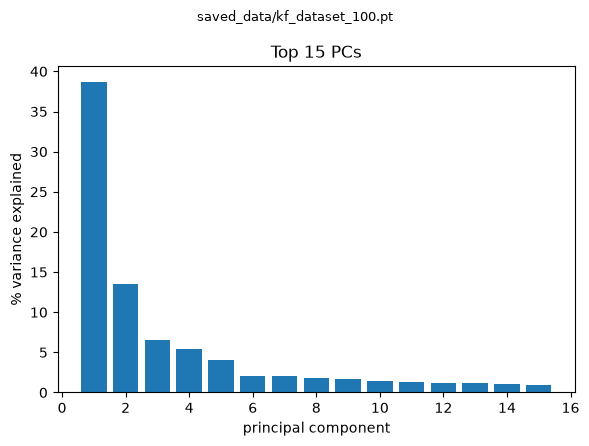

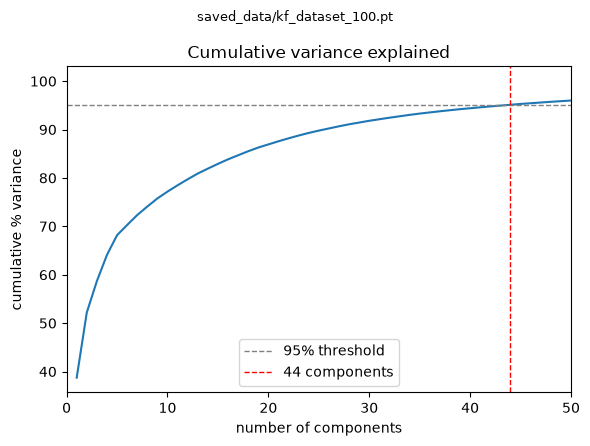

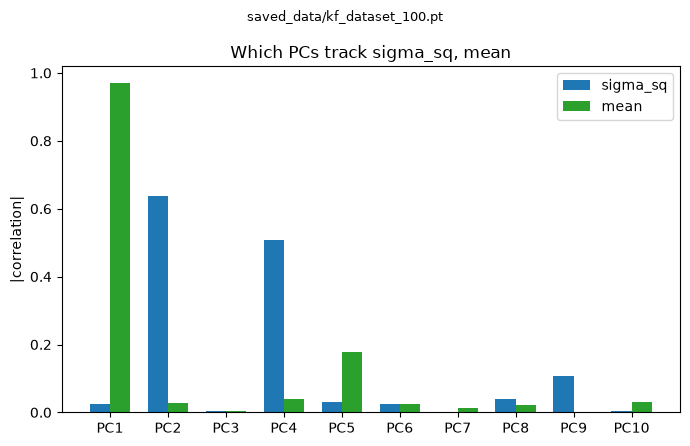

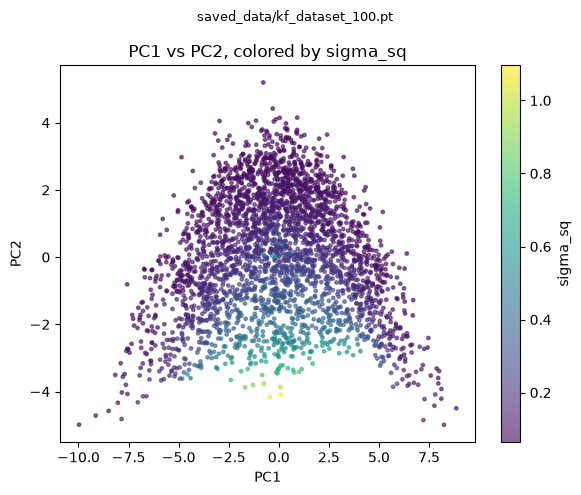

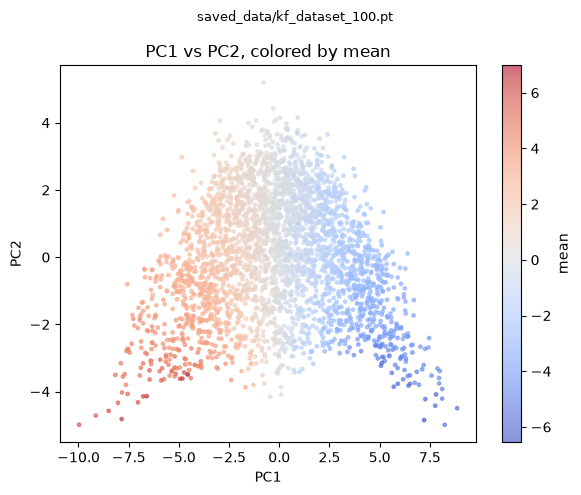

Saved pca_analysis_scree.png
Saved pca_analysis_cumvar.png
Saved pca_analysis_pc_corr_bars.png
Saved pca_analysis_pc1_pc2_sigma.png
Saved pca_analysis_pc1_pc2_mu.png
Saved pca_analysis_best_axes.png


{'dataset_path': 'saved_data/kf_dataset_100.pt',
 'n_components_for_95pct': 44,
 'pc1_variance_pct': np.float32(38.73453),
 'top_sigma_pc': 2,
 'top_sigma_pc_corr': np.float64(-0.637021541595459),
 'top_mu_pc': 1,
 'top_mu_pc_corr': np.float64(-0.9709690809249878),
 'same_pc_dominates_both': False}

In [12]:
fname = "saved_data/kf_dataset_100.pt"
pca_analysis(dataset_path=fname, output_plot_path="pca_analysis.png")

## How to read the output

- **"Components needed for 95% of variance"**: the network's effective
  dimensionality. A number well below 200 (e.g. 40-65) means most units'
  activity is redundant with a smaller set of underlying directions.
- **Per-PC correlation table**: look for whether the PC with the strongest
  `sigma_sq` correlation is different from the PC with the strongest `mu`
  correlation. Same PC dominating both = entangled code on this axis;
  different PCs = at least partial separation.
- **PC1 vs PC2 scatter plots**: compare the two color-coded versions (by
  `sigma_sq`, by `mu`) side by side. If the color gradients run in visibly
  different directions through the same point cloud, that's the geometric
  signature of separation -- the two variables vary along different axes of
  the same population.
